# Reconstructing images
to change the model, overwrite:
- MODEL variable;
- QUANT_TABLES variable if necessary;
- the degradation function.


## Importing and Loading

In [ ]:
! pip install kornia
! pip install torch_dct
! pip install torchgeometry


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 67.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 132.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.7/42.7 kB 3.6 MB/s eta 0:00:00


In [ ]:
# IMPORTS
import random
from PIL import Image
import torchvision.transforms as T
import matplotlib.pyplot as plt
import torch
import os
import sys
from pathlib import Path

import kornia
import torch_dct as dct

from types import MethodType
import gc


from torch._prims_common import check

from collections import OrderedDict
import copy

# reconstruction
import os
import glob
import torch
from PIL import Image
import torchvision.transforms as T
import torchvision.utils as vutils

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# Base path
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/tesi/" if 'google.colab' in str(get_ipython()) else "."
MODEL = "07_dequant-quant_weight_decay"
NAME = "07_recon_weight_decay"

# Directories
ZIP_PATH = os.path.join(BASE_DIR, "data", "img_align_celeba.zip")
LOCAL_DATA_ROOT = "/content/raw_data"
SRC_C_D = os.path.join(BASE_DIR, "src", "Cold-Diffusion-Models", "resolution-diffusion-pytorch", "resolution_diffusion_pytorch")
QUANT_TABLES = os.path.join(BASE_DIR, "assets/dequant-quant3_qt.pt")


CHECKPOINT_DIR = os.path.join(BASE_DIR, "checkpoints", "coeff_quantized", "1_final_degradation_function", MODEL)
TRAINED_MODEL_DIR = os.path.join(BASE_DIR, "trained_models", "cold_diffusion", "coeff_quantized", "1_final_degradation_function", MODEL)

OUTPUT_DIR = os.path.join(BASE_DIR, "outputs", "reconstructions",  "coeff_quantized", NAME)

# restoration
VAE_FACES_DIR = os.path.join(BASE_DIR, 'data', 'generated_images')

# importing the models
if SRC_C_D not in sys.path:
    sys.path.append(os.path.dirname(SRC_C_D))

# Folder creation
for path in [CHECKPOINT_DIR, OUTPUT_DIR, TRAINED_MODEL_DIR]:
    os.makedirs(path, exist_ok=True)

In [ ]:
tot_generated_images = 100

In [ ]:
# custom_module_path = SRC_C_D # Use the already defined SRC_C_D from cell 7NbO8fuZkb7l
# if custom_module_path not in sys.path:
#     sys.path.insert(0, custom_module_path)

from resolution_diffusion_pytorch import Unet, GaussianDiffusion, Trainer

dataset_path = os.path.join(LOCAL_DATA_ROOT, "img_align_celeba")
model_path = os.path.join(TRAINED_MODEL_DIR, f'{MODEL}.pt')
quant_tables = torch.load(QUANT_TABLES)

In [ ]:
# State shared between consecutive steps - valid just as long as q_sample lasts
_dct_state = {
    'coeffs': None,     # real DCT coefficients (not quantized) - updated at each step
    'step': -1,         # last step applied
}

def get_quant_table_tensor(step, device):
    lum  = quant_tables[f'step{step}_luminance'].to(device)    # [8, 8]
    chrom = quant_tables[f'step{step}_chrominance'].to(device) # [8, 8]
    return lum, chrom

def img_to_dct_blocks(img_batch):
    """
    Pixel space [-1,1] -> DCT coefficients, frequency space.
    Returns (blocks_dct, bH, bW) where blocks_dct shape [B, C, bH*bW, 8, 8].
    """
    B, C, H, W = img_batch.shape
    x = (img_batch + 1) * 0.5                          # [-1,1] -> [0,1]
    x_ycbcr = kornia.color.rgb_to_ycbcr(x)             # [0,1] YCbCr
    x_255 = x_ycbcr * 255.0                            # [0,255]

    blocks = x_255.unfold(2, 8, 8).unfold(3, 8, 8)     # [B,C,bH,bW,8,8]
    bH, bW = blocks.shape[2], blocks.shape[3]
    blocks_flat = blocks.contiguous().reshape(B, C, bH * bW, 8, 8)
    dct_blocks = dct.dct_2d(blocks_flat, norm='ortho')  # [B,C,bH*bW,8,8]
    return dct_blocks, bH, bW

def dct_blocks_to_img(dct_blocks, bH, bW, B, C, H, W):
    """
    DCT coefficients → pixel space [-1,1].
    """
    result_flat = dct.idct_2d(dct_blocks, norm='ortho')
    result = result_flat.reshape(B, C, bH, bW, 8, 8)
    result = result.permute(0, 1, 2, 4, 3, 5).contiguous().reshape(B, C, H, W)
    result_01 = (result / 255.0).clamp(0, 1)
    result_rgb = kornia.color.ycbcr_to_rgb(result_01)
    return (result_rgb * 2 - 1).clamp(-1, 1)

def quantize_dct(dct_blocks, q_lum, q_chrom):
    """
    Quantizes DCT coefficients with luma/chroma tables.
    Returns quantized coefficients, not divided by q yet.
    """
    q_lum   = q_lum.unsqueeze(0).unsqueeze(0)    # [1,1,8,8]
    q_chrom = q_chrom.unsqueeze(0).unsqueeze(0)  # [1,1,8,8]
    out = dct_blocks.clone()
    out[:, 0:1] = torch.round(dct_blocks[:, 0:1] / q_lum)   * q_lum
    # out[:, 1:3] = torch.round(dct_blocks[:, 1:3] / q_chrom) * q_chrom
    return out

def dequantize_dct(dct_blocks, q_lum, q_chrom):
    """
    Dequantizes DCT coefficients with luma/chroma tables.
    Thanks to the saved original coefficients,
    and since the current coefficients are already real,
    this funtion does nothing.
    """
    return dct_blocks

def jpeg_degradation(img_batch, step):
    """
    Cumulative JPEG degradation in frequence space

    - step = 0: no degradation, resets state
    - step = 1: DCT from zero on original image -> quantize with table [1]
    - step > 1: quantizes with table [t] -> update state
    """
    device = img_batch.device
    current_step = step.item() if torch.is_tensor(step) else step

    if current_step == 0:
        # Reset state, no degradation
        _dct_state['coeffs'] = None
        _dct_state['step'] = -1
        return img_batch

    B, C, H, W = img_batch.shape

    if current_step == 1 or _dct_state['coeffs'] is None:
        # The first step compute DCT coefficients
        dct_blocks, bH, bW = img_to_dct_blocks(img_batch)
        _dct_state['original_dct'] = dct_blocks.clone()  # save original
        _dct_state['bH'] = bH
        _dct_state['bW'] = bW
    else:
        # Other steps: always starts from x0 for applying the new table
        dct_blocks = _dct_state['original_dct'].to(device)
        bH = _dct_state['bH']
        bW = _dct_state['bW']

    # Apply current step table directly on original coefficients
    q_lum, q_chrom = get_quant_table_tensor(current_step, device)
    quantized = quantize_dct(dct_blocks, q_lum, q_chrom)

    # Update the state
    _dct_state['coeffs'] = quantized
    _dct_state['step'] = current_step

    return dct_blocks_to_img(quantized, bH, bW, B, C, H, W)


In [ ]:
# Out Of Memory problems
torch.cuda.synchronize()
gc.collect()
torch.cuda.empty_cache()
print(f"Free GPU memory: {torch.cuda.mem_get_info()[0] / 1e9:.2f} GB")

def new_sample(self, batch_size=16, img=None, t=None):
    '''
    Images direct reconstruction
    '''

    if t is None:
        t = self.num_timesteps

    xt = img # image at maximum degraded step

    direct_recons = None

    while t:
        with torch.no_grad():
            step = torch.full((batch_size,), t - 1, dtype=torch.long).cuda()
            # Denoise x_t to get an estimate of x_0 (denoted as 'x')
            x = self.denoise_fn(img, step)

            if self.train_routine == 'Final':
                if direct_recons is None:
                    direct_recons = x

                if self.sampling_routine == 'default':
                    img = jpeg_degradation(x, t - 1)

                elif self.sampling_routine == 'x0_step_down':
                    x_times = jpeg_degradation(x, t)
                    x_times_sub_1 = jpeg_degradation(x, t - 1)
                    img = img - x_times + x_times_sub_1

        t -= 1

    return xt, direct_recons, img

Free GPU memory: 15.53 GB


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE = 128

def find_last_checkpoint(save_folder):
    path = os.path.join(save_folder, f'model.pt')
    if os.path.exists(path):
        return path
    return None

In [ ]:
# --- CONFIGURATION ---
class Args:
    time_steps = 9
    train_steps = 5000
    save_folder = OUTPUT_DIR
    data_path = dataset_path
    checkpoint_path = CHECKPOINT_DIR
    load_path = find_last_checkpoint(checkpoint_path)
    train_routine = 'Final'
    resolution_routine = 'Incremental'
    sampling_routine = 'x0_step_down'
    image_size = IMG_SIZE
    channels = 3

args = Args()

# --- MODEL INITIALIZATION ---
model = Unet(
    dim = 64,
    dim_mults = (1, 2, 4, 8),
    channels = args.channels
).cuda()

diffusion = GaussianDiffusion(
    model,
    image_size = args.image_size,
    device_of_kernel = 'cuda',
    channels = args.channels,
    timesteps = args.time_steps,
    loss_type = 'l1',
    resolution_routine = args.resolution_routine,
    train_routine = args.train_routine,
    sampling_routine = args.sampling_routine
).cuda()

if torch.cuda.device_count() > 1:
    diffusion = torch.nn.DataParallel(diffusion)

Is Time embed used ?  True


<!-- ## Resources
[] -->

In [ ]:
trained_model = torch.load(model_path)

new_state_dict = OrderedDict()
for k, v in trained_model.items():
    new_key = k.replace('module.', '', 1)
    new_state_dict[new_key] = v

if isinstance(diffusion, torch.nn.DataParallel):
    diffusion.module.load_state_dict(new_state_dict)
    print("Model loaded into DataParallel wrapper.")
else:
    diffusion.load_state_dict(new_state_dict)
    print("Model loaded directly.")

# Create ema_model as a deep copy of the loaded diffusion model
# This bypasses the Trainer initialization which requires a dataset
ema_model = copy.deepcopy(diffusion)
print("EMA model created as a deep copy.")

# OVERWRITING
if isinstance(diffusion, torch.nn.DataParallel):
    diffusion.module.func = [lambda img, s=i: jpeg_degradation(img, s) for i in range(args.time_steps)]
    ema_model.module.func = [lambda img, s=i: jpeg_degradation(img, s) for i in range(args.time_steps)]
else:
    diffusion.func = [lambda img, s=i: jpeg_degradation(img, s) for i in range(args.time_steps)]
    ema_model.func = [lambda img, s=i: jpeg_degradation(img, s) for i in range(args.time_steps)]


# Patch the `sample` method for both diffusion and ema_model
# Get the inner models if DataParallel
inner_diffusion = diffusion.module if isinstance(diffusion, torch.nn.DataParallel) else diffusion
inner_ema_model = ema_model.module if isinstance(ema_model, torch.nn.DataParallel) else ema_model

# Apply the new_sample patch to the `sample` method (instead of q_sample)
inner_diffusion.sample = MethodType(new_sample, inner_diffusion)
inner_ema_model.sample = MethodType(new_sample, inner_ema_model)


# Set models to evaluation mode
diffusion.eval()
ema_model.eval()
print("Model and EMA model loaded, patched, and set to eval mode.")

Model loaded directly.
EMA model created as a deep copy.
Model and EMA model loaded, patched, and set to eval mode.


In [ ]:
import os
import glob
import torch
from PIL import Image
import torchvision.transforms as T
import torchvision.utils as vutils

In [ ]:
IMG_SIZE = 128            # must be the same as in the trained model
TIME_STEPS = 9            # must be the same as in the trained model
BATCH_SIZE = 64

In [ ]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

# loading images
to_tensor = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),    # for safety. should be no-op
    T.ToTensor(),                      # -> [0,1]
])


In [ ]:
def load_batch_as_minus1_1(paths):
    imgs = [to_tensor(Image.open(p).convert('RGB')) for p in paths]
    batch = torch.stack(imgs, dim=0)   # [B,3,H,W] in [0,1]
    batch = batch * 2 - 1              # -> [-1,1], range for denoise_fn/Unet
    return batch.cuda()

def save_reconstructions(tensor_minus1_1, start_idx, dir_):
    imgs = (tensor_minus1_1.clamp(-1, 1) + 1) / 2   # -> [0,1] per il salvataggio
    for i, img in enumerate(imgs):
        vutils.save_image(img, os.path.join(dir_, f'recon_{start_idx + i:06d}.jpg'))

In [ ]:
# equivalent to direct_recon
def reconstruct_direct(diffusion_model, img_batch, time_steps):
    """
    Returns the direct reconstruction of the image.
    """
    batch_size = img_batch.shape[0]
    step = torch.full((batch_size,), time_steps - 1, dtype=torch.long).cuda()
    with torch.no_grad():
        direct_recons = diffusion_model.denoise_fn(img_batch, step)
    return direct_recons

def reconstruct_indirect(diffusion_model, img_batch, time_steps):
  with torch.no_grad():
    batch_size_val = img_batch.shape[0]
    # note: here the images in img_batch are already at maximum degradation step,
    # no further degradation is needed
    xt, direct_recons, restored = diffusion_model.sample(
        batch_size=batch_size_val,
        img=img_batch,
        t=time_steps
    )
    return restored

In [ ]:
def run(diffusion_model, num_images_to_process = 10, direct = True, output_directory=OUTPUT_DIR):
    paths = sorted(glob.glob(os.path.join(VAE_FACES_DIR, '*.jpg')))
    print(f'Found {len(paths)} syntetic images to reconstruct')

    for start in range(0, min(len(paths), num_images_to_process), BATCH_SIZE):
        batch_paths = paths[start:start + BATCH_SIZE]
        img_batch = load_batch_as_minus1_1(batch_paths)

        if direct:
          direct_recons = reconstruct_direct(diffusion_model, img_batch, TIME_STEPS)
        else:
          direct_recons = reconstruct_indirect(diffusion_model, img_batch, TIME_STEPS)

        save_reconstructions(direct_recons.cpu(), start, output_directory)
        del img_batch, direct_recons
        torch.cuda.empty_cache()

    print(f'Reconstructions saved in: {output_directory}')

In [ ]:
def plot_some_reconstructions(num_images_to_plot = 4, output_directory = OUTPUT_DIR, direct = True):
    # Get a list of all reconstructed image paths
    reconstructed_image_paths = sorted(glob.glob(os.path.join(output_directory, 'recon_*.jpg')))

    # Get a list of original degraded image paths (these are the inputs to the reconstruction)
    original_image_paths = sorted(glob.glob(os.path.join(VAE_FACES_DIR, '*.jpg')))

    # Select the first 'num_images_to_plot' images from both lists
    images_to_display_recon = reconstructed_image_paths[:num_images_to_plot]
    images_to_display_orig = original_image_paths[:num_images_to_plot]

    if not images_to_display_recon or not images_to_display_orig:
        print(f"No reconstructed or original images found in {output_directory} or {VAE_FACES_DIR}")
    else:
        fig, axes = plt.subplots(2, num_images_to_plot, figsize=(num_images_to_plot * 4, 8))
        if direct:
            fig.suptitle('Original Degraded vs. Reconstructed Images - direct', fontsize=16)
        else:
            fig.suptitle('Original Degraded vs. Reconstructed Images - indirect', fontsize=16)

        for i in range(num_images_to_plot):
            # Plot original degraded image
            orig_img = Image.open(images_to_display_orig[i])
            axes[0, i].imshow(orig_img)
            axes[0, i].set_title(f'Original {i+1}')
            axes[0, i].axis('off')

            # Plot reconstructed image
            recon_img = Image.open(images_to_display_recon[i])
            axes[1, i].imshow(recon_img)
            axes[1, i].set_title(f'Recon {i+1}')
            axes[1, i].axis('off')

        plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
        plt.show()

### Reconstruction
Finally, now the call to the run function performs reconstruction of the degradated images, previously generated by the VAE.

Both direct and undirect methods can be used. Both will be plotted for visual comparison.

In [ ]:
output_directory_dir = os.path.join(OUTPUT_DIR, "direct_recon")
os.makedirs(output_directory_dir, exist_ok=True)

output_directory_indir = os.path.join(OUTPUT_DIR, "indirect_recon")
os.makedirs(output_directory_indir, exist_ok=True)

run(ema_model, num_images_to_process=tot_generated_images, direct=True, output_directory=output_directory_dir)

run(ema_model, num_images_to_process=tot_generated_images, direct=False, output_directory=output_directory_indir)

Found 5000 syntetic images to reconstruct
Reconstructions saved in: /content/drive/MyDrive/Colab Notebooks/tesi/outputs/reconstructions/07_recon_weight_decay/direct_recon
Found 5000 syntetic images to reconstruct
Reconstructions saved in: /content/drive/MyDrive/Colab Notebooks/tesi/outputs/reconstructions/07_recon_weight_decay/indirect_recon


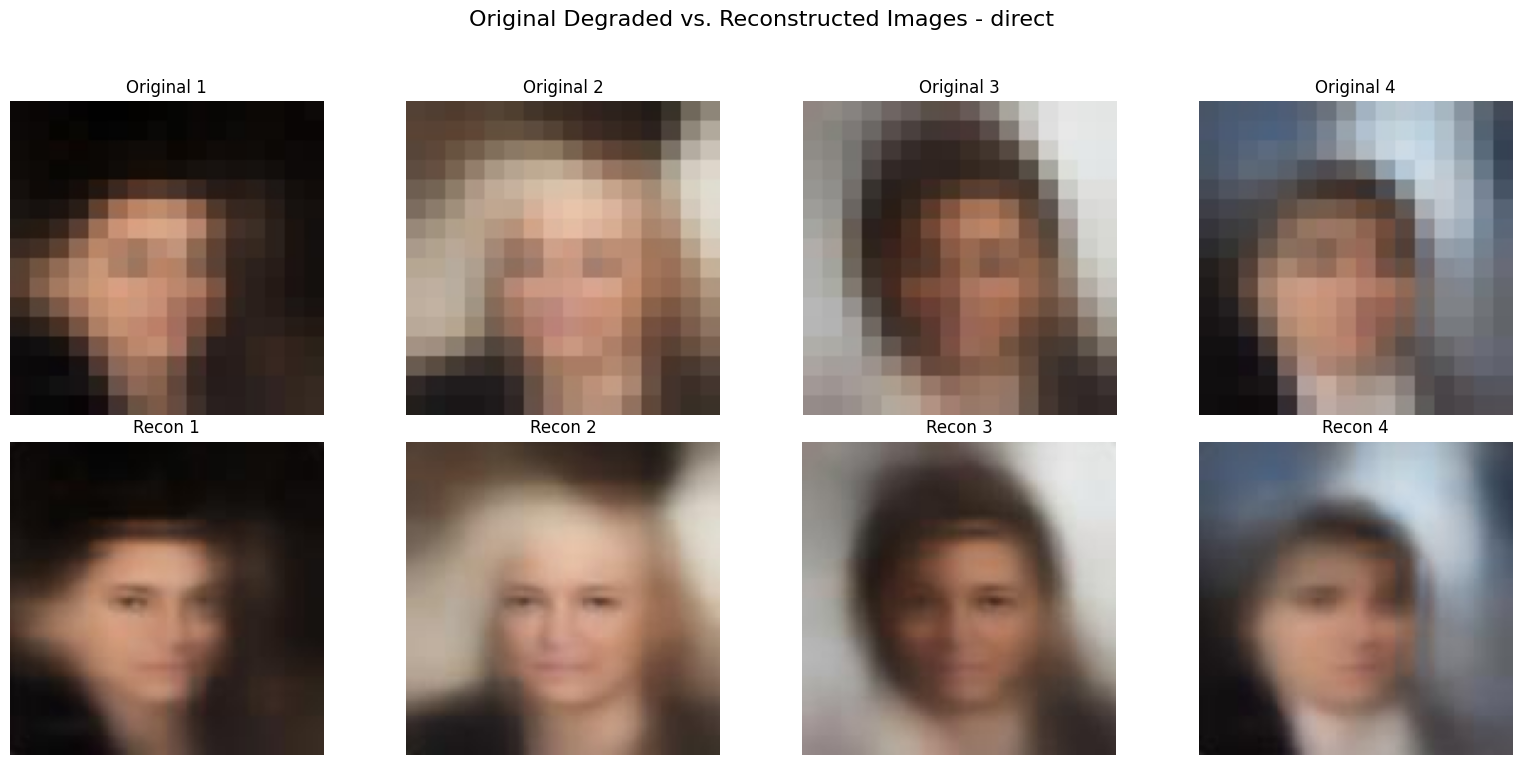

In [ ]:
plot_some_reconstructions(output_directory=output_directory_dir, direct=True)

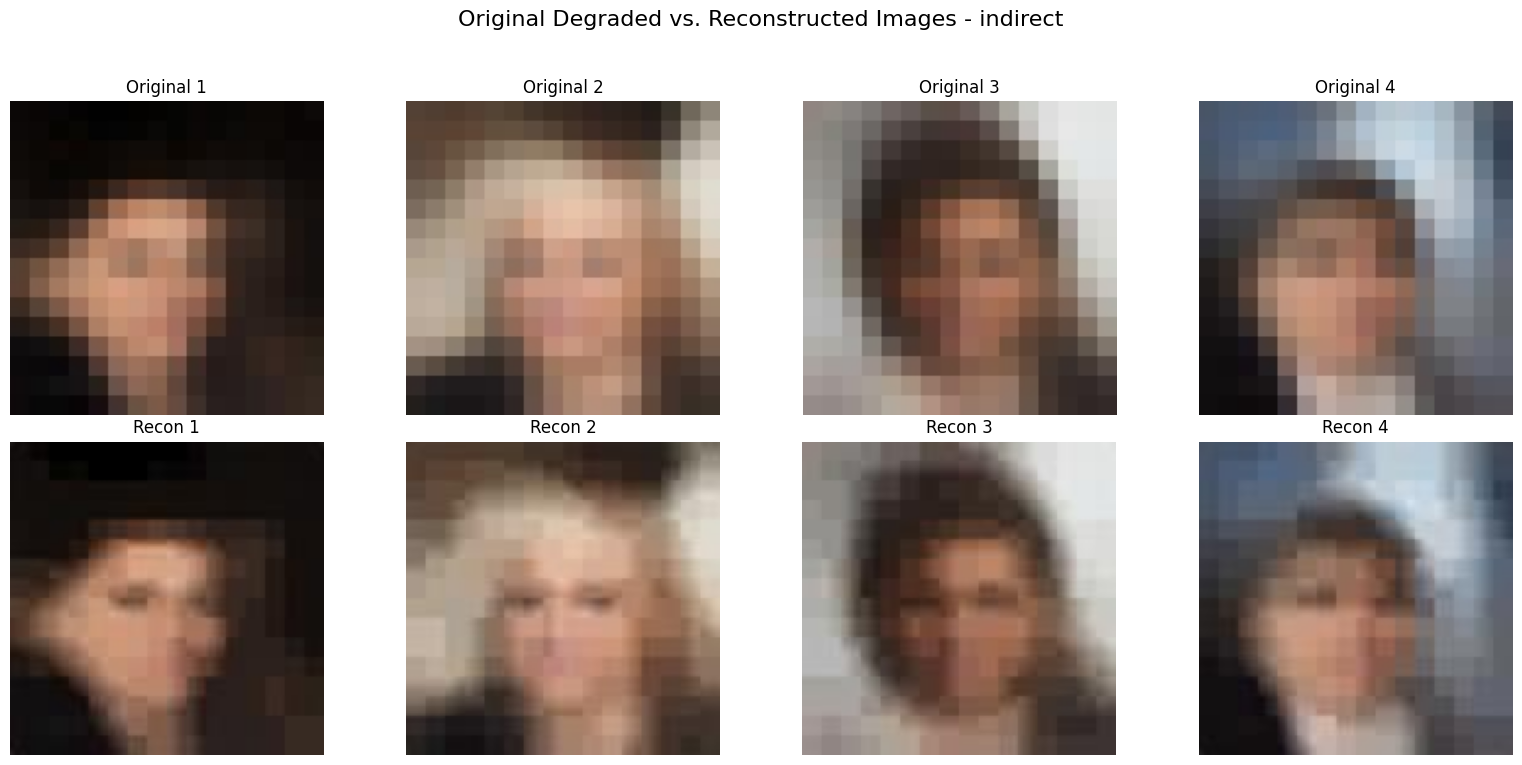

In [ ]:
plot_some_reconstructions(output_directory=output_directory_indir, direct=False)